### Команда для запуска эксперимента

__ВАЖНО:__ надо менять папку с конфигом эксперимента и output_dir

In [ ]:
# accelerate launch ./mult_3_dreambooth/train_dreambooth_lora_sdxl.py   --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0"   --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix"   --instance_data_dir="./dataset/few_shot/instance_images"   --class_data_dir="./dataset/few_shot/class_images"   --instance_prompt="a photo of a sks dog"   --class_prompt="a photo of a dog"   --output_dir="./mult_3_dreambooth"   --resolution=1024   --train_batch_size=1   --gradient_accumulation_steps=1   --learning_rate=1e-4   --lr_scheduler="constant"   --lr_warmup_steps=0   --max_train_steps=500   --checkpointing_steps=100   --mixed_precision="fp16"   --enable_xformers_memory_efficient_attention   --gradient_checkpointing   --with_prior_preservation   --prior_loss_weight=1.0   --seed=42

In [ ]:
# accelerate launch ./base_dynamic/train_dreambooth_lora_sdxl.py   --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0"   --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix"   --instance_data_dir="./dataset/few_shot/instance_images"   --class_data_dir="./dataset/few_shot/class_images"   --instance_prompt="a photo of a sks dog"   --class_prompt="a photo of a dog"   --output_dir="./base_dynamic"   --resolution=1024   --train_batch_size=1   --gradient_accumulation_steps=1   --learning_rate=1e-4   --lr_scheduler="constant"   --lr_warmup_steps=0   --max_train_steps=1000   --checkpointing_steps=100   --mixed_precision="fp16"   --enable_xformers_memory_efficient_attention   --gradient_checkpointing   --with_prior_preservation   --prior_loss_weight=1.0   --seed=42

In [2]:
# accelerate launch ./mult_1_right_dynamic_one_shot/train_dreambooth_lora_sdxl.py   --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0"   --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix"   --instance_data_dir="./dataset/few_shot/instance_images_one"   --class_data_dir="./dataset/few_shot/class_images"   --instance_prompt="a photo of a sks dog"   --class_prompt="a photo of a dog"   --output_dir="./mult_1_right_dynamic_one_shot"   --resolution=1024   --train_batch_size=1   --gradient_accumulation_steps=1   --learning_rate=1e-4   --lr_scheduler="constant"   --lr_warmup_steps=0   --max_train_steps=1000   --checkpointing_steps=100   --mixed_precision="fp16"   --enable_xformers_memory_efficient_attention   --gradient_checkpointing   --with_prior_preservation   --prior_loss_weight=1.0   --seed=42

### Библиотеки

In [3]:
import torch

import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
sns.set_style("darkgrid")

### Визуализация распределений

<Axes: ylabel='Count'>

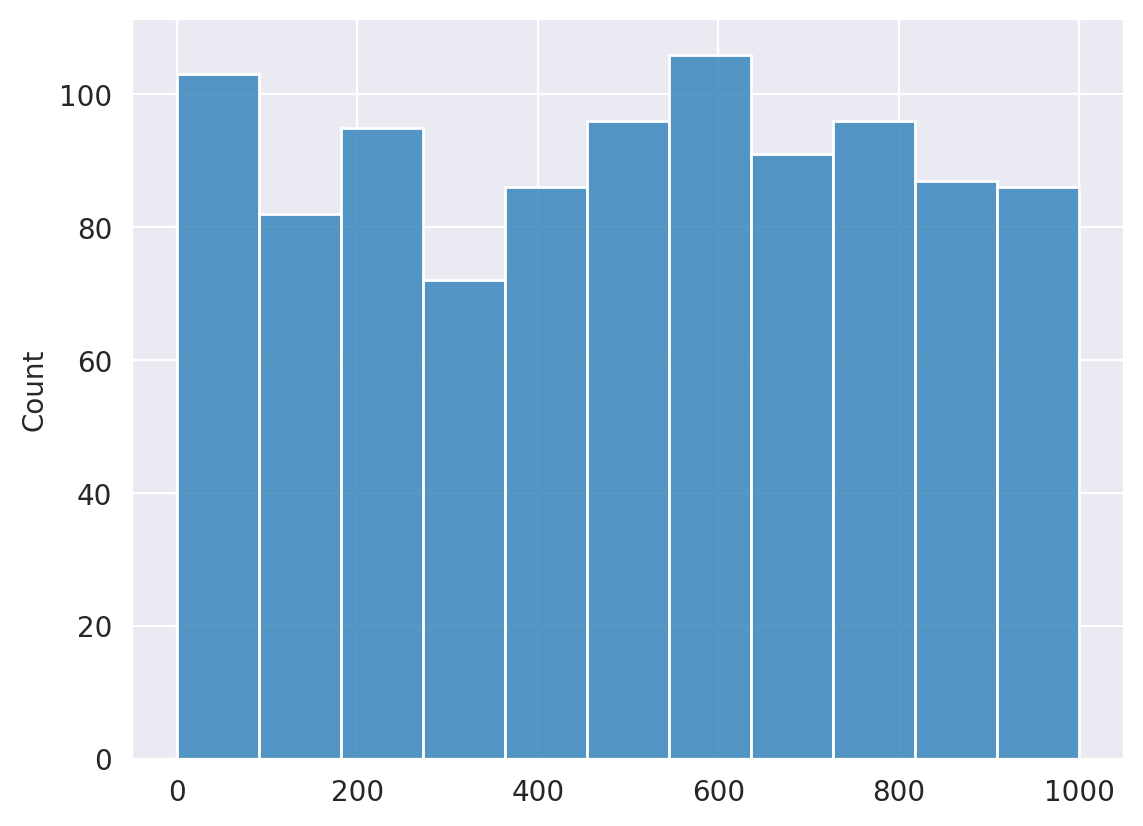

In [4]:
idx =  torch.randint(0, 1000, (1000, ))
sns.histplot(idx)

In [5]:
def sample_timesteps_power(T, bsz, alpha=3.0, device="cpu"):
    """
    Sample timesteps with power bias toward later (low-noise) steps.
    T: total number of timesteps
    bsz: batch size
    alpha: bias strength (bigger => more samples near t=0)
    """
    t = torch.arange(T, dtype=torch.float32, device=device)
    tau = t / (T - 1)                      # normalize 0..1
    probs = (1.0 - tau) ** alpha   # bias distribution
    probs = probs / probs.sum()            # normalize to sum=1
    idx = torch.multinomial(probs, bsz, replacement=True)
    return idx, probs[idx]

<Axes: ylabel='Count'>

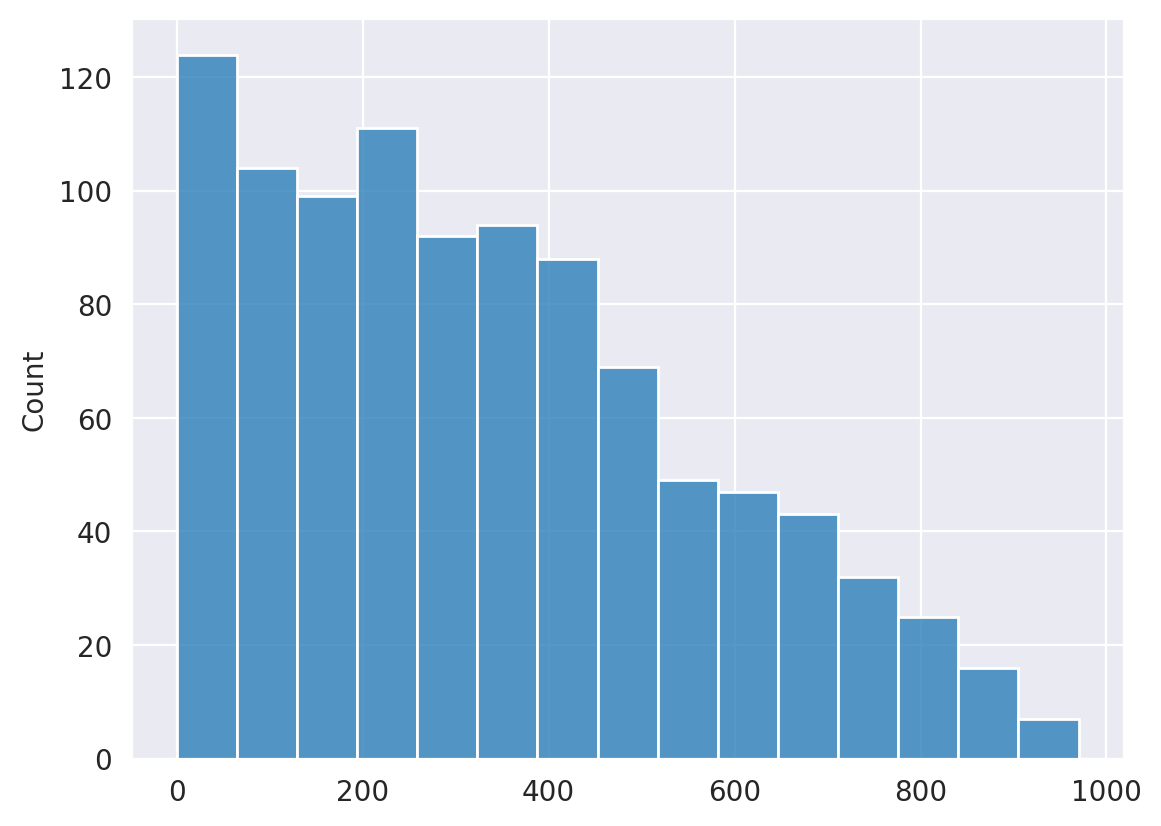

In [6]:
idx, probs = sample_timesteps_power(1000, 1000, alpha=1, device="cpu")
sns.histplot(idx)

In [7]:
def sample_timesteps_power_right_tail(T, bsz, alpha=3.0, device="cpu"):
    """
    Sample timesteps with power bias toward earlier (high-noise) steps.
    T: total number of timesteps
    bsz: batch size
    alpha: bias strength (bigger => more samples near t=T-1)
    """
    t = torch.arange(T, dtype=torch.float32, device=device)
    tau = t / (T - 1)                     # normalize 0..1
    probs = tau ** alpha                  # bias toward large t
    probs = probs / probs.sum()           # normalize
    idx = torch.multinomial(probs, bsz, replacement=True)
    return idx, probs[idx]

<Axes: ylabel='Count'>

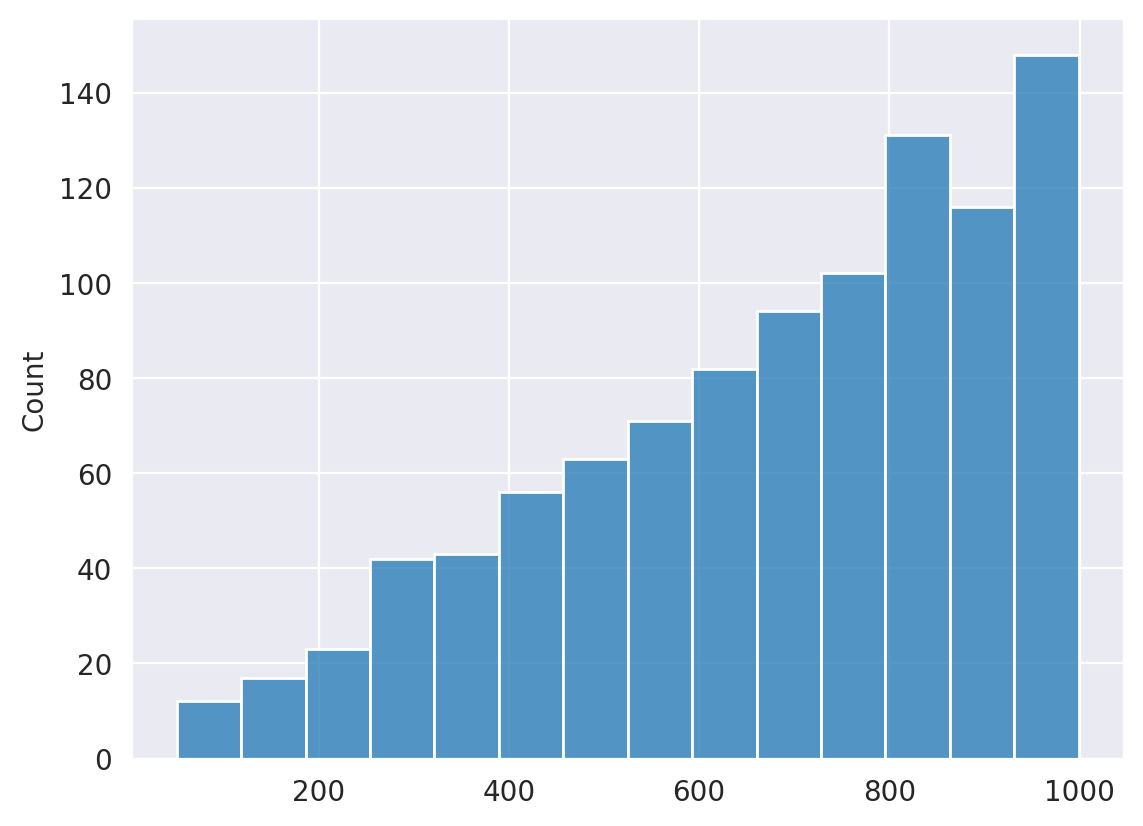

In [8]:
idx, probs = sample_timesteps_power_right_tail(1000, 1000, alpha=1, device="cpu")
sns.histplot(idx)

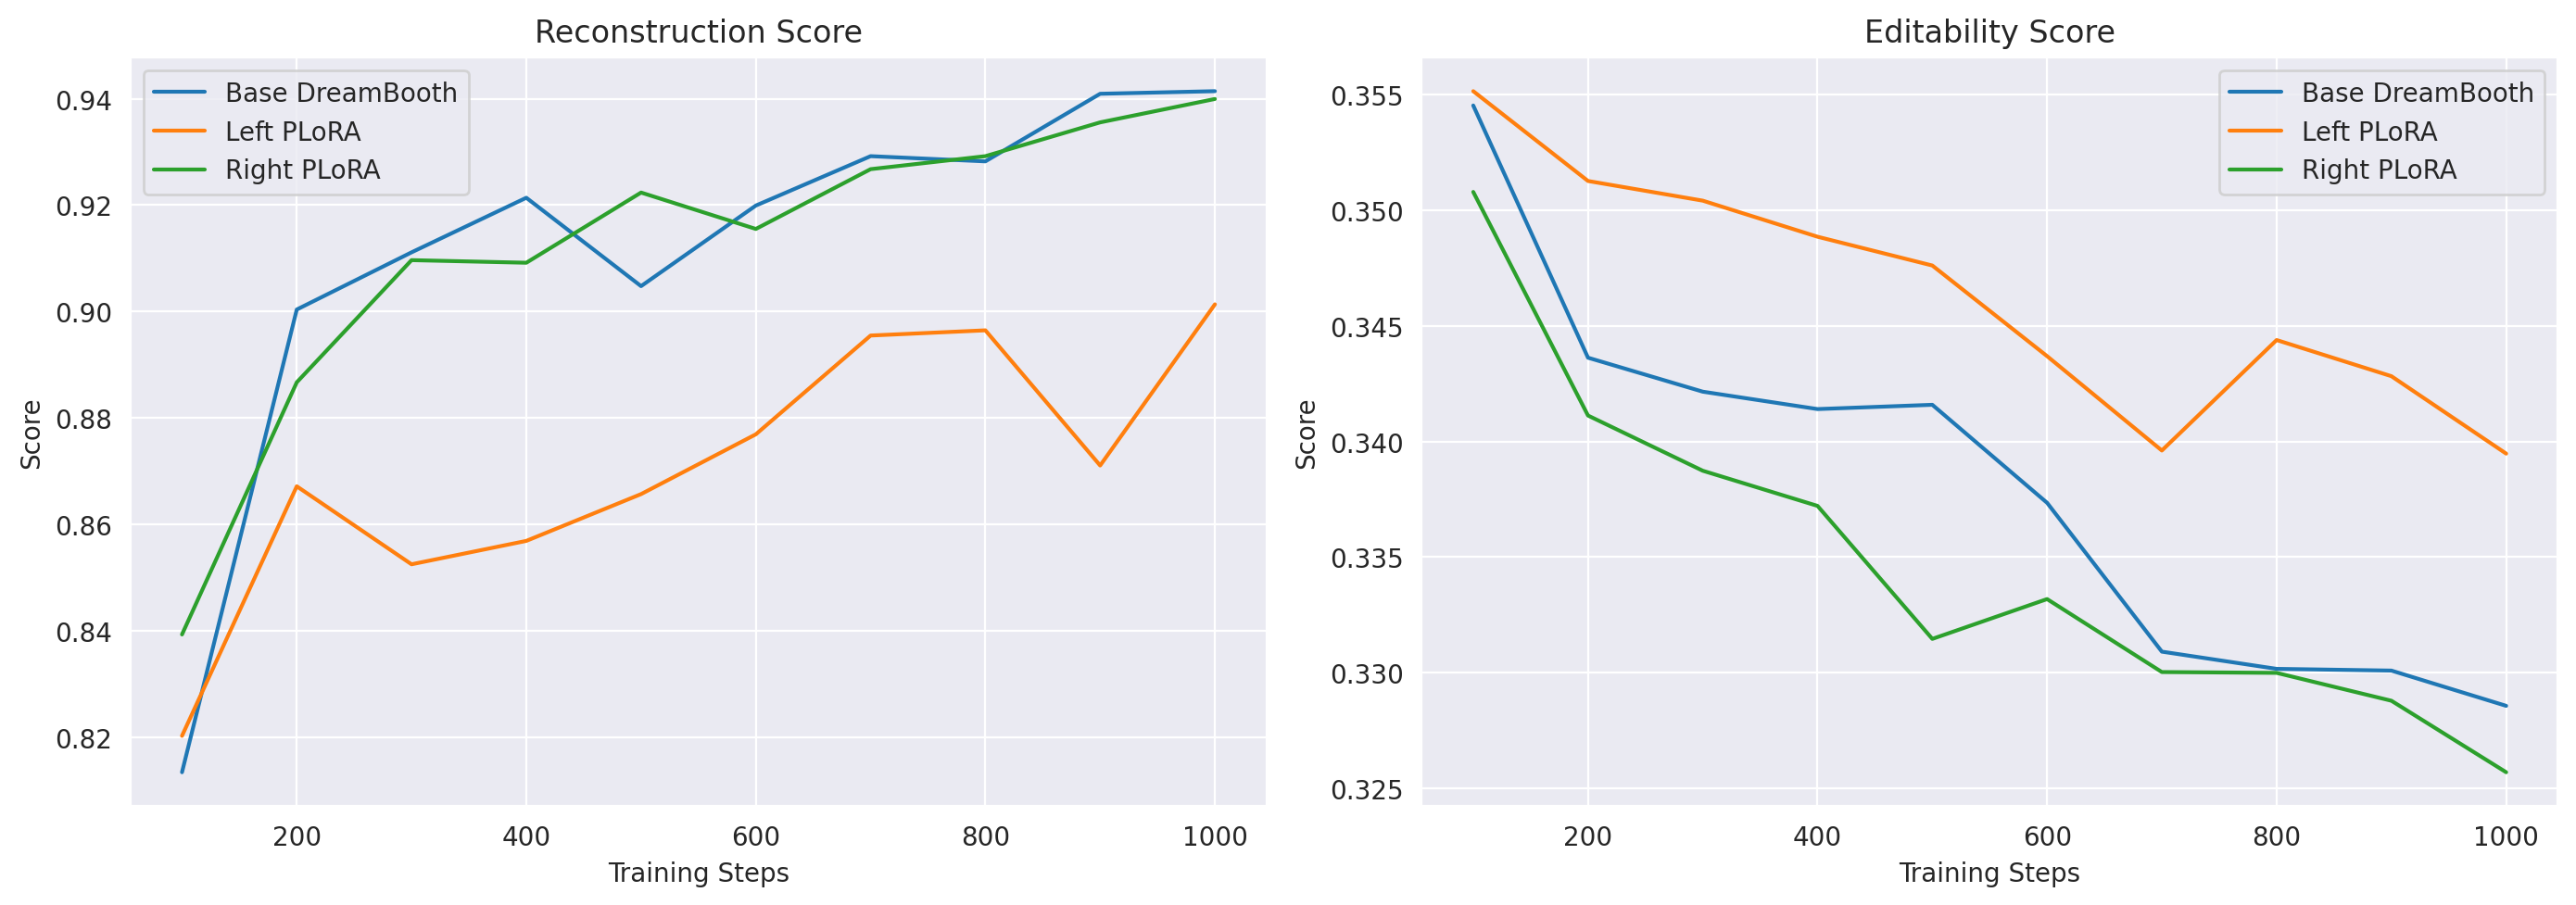

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# few_shot
base_rec = {100: 0.8134765625,
 200: 0.900390625,
 300: 0.9111328125,
 400: 0.92138671875,
 500: 0.90478515625,
 600: 0.919921875,
 700: 0.92919921875,
 800: 0.92822265625,
 900: 0.94091796875,
 1000: 0.94140625}

base_edit = {100: 0.35452368951612906,
 200: 0.34362005418346775,
 300: 0.3421512726814516,
 400: 0.34139916204637094,
 500: 0.34158423639112906,
 600: 0.3373472152217742,
 700: 0.3309129284274194,
 800: 0.33016869329637094,
 900: 0.3300938760080645,
 1000: 0.32856996597782256}

left_rec = {100: 0.8203125,
 200: 0.8671875,
 300: 0.8525390625,
 400: 0.85693359375,
 500: 0.86572265625,
 600: 0.876953125,
 700: 0.8955078125,
 800: 0.896484375,
 900: 0.87109375,
 1000: 0.9013671875}

left_edit = {100: 0.3551419165826613,
 200: 0.35125929309475806,
 300: 0.3504087386592742,
 400: 0.3488493888608871,
 500: 0.3476050592237903,
 600: 0.34368699596774194,
 700: 0.33960748487903225,
 800: 0.34438397807459675,
 900: 0.34282069052419356,
 1000: 0.3394736013104839}

right_rec = {100: 0.83935546875,
 200: 0.88671875,
 300: 0.90966796875,
 400: 0.9091796875,
 500: 0.92236328125,
 600: 0.91552734375,
 700: 0.9267578125,
 800: 0.92919921875,
 900: 0.935546875,
 1000: 0.93994140625}

right_edit = {100: 0.35078676285282256,
 200: 0.3411195816532258,
 300: 0.3387333039314516,
 400: 0.3372133316532258,
 500: 0.33146421370967744,
 600: 0.3331850113407258,
 700: 0.33003087197580644,
 800: 0.3299954322076613,
 900: 0.3287904800907258,
 1000: 0.3256993447580645}

# ---- PLOTTING ----
steps = list(base_rec.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec.values(), label="Base DreamBooth")
axs[0].plot(steps, left_rec.values(), label="Left PLoRA")
axs[0].plot(steps, right_rec.values(), label="Right PLoRA")

axs[0].set_title("Reconstruction Score")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_edit.values(), label="Base DreamBooth")
axs[1].plot(steps, left_edit.values(), label="Left PLoRA")
axs[1].plot(steps, right_edit.values(), label="Right PLoRA")

axs[1].set_title("Editability Score")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

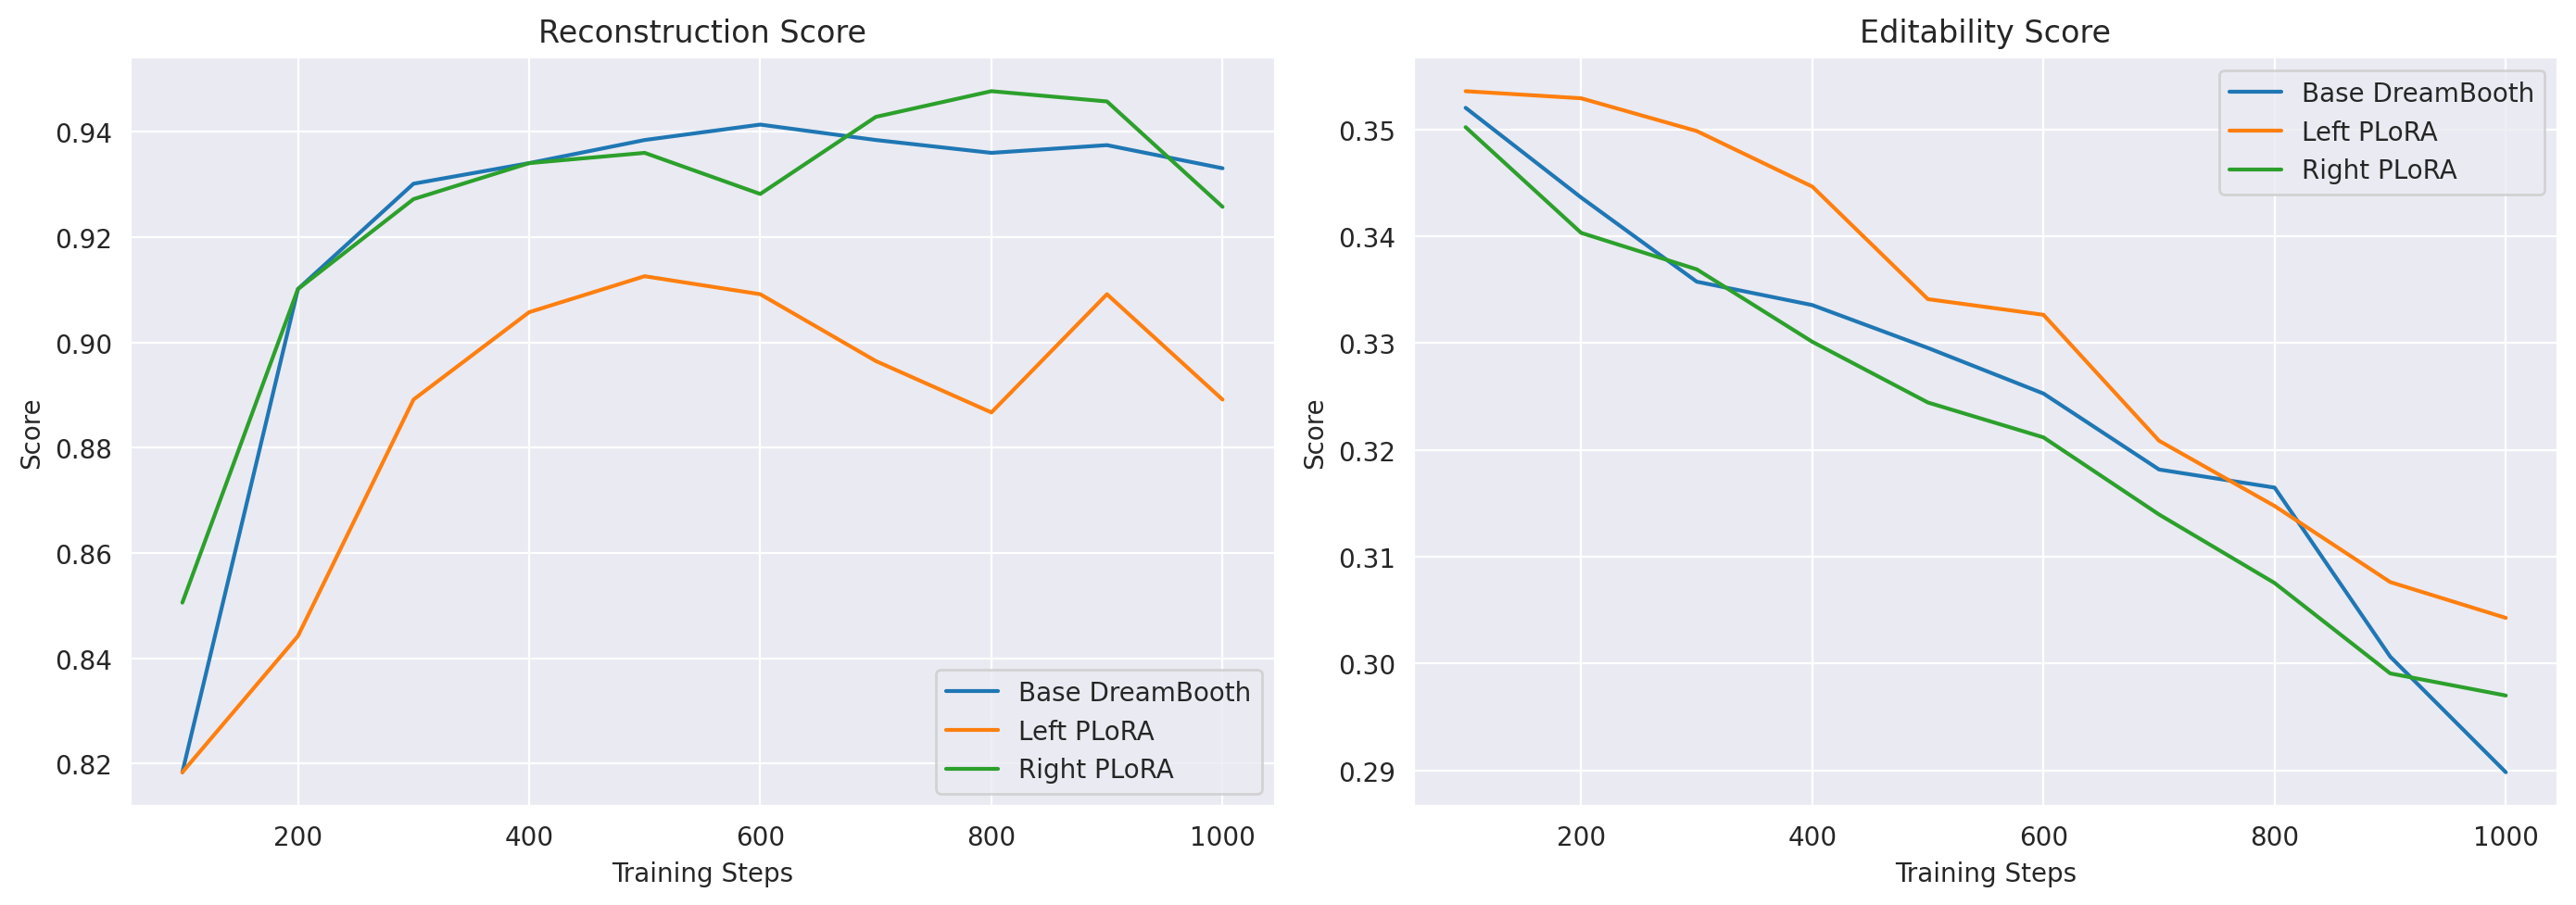

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# one shot

base_rec = {100: 0.818359375,
 200: 0.91015625,
 300: 0.93017578125,
 400: 0.93408203125,
 500: 0.9384765625,
 600: 0.94140625,
 700: 0.9384765625,
 800: 0.93603515625,
 900: 0.9375,
 1000: 0.93310546875}

base_edit = {100: 0.35202715473790325,
 200: 0.3436239919354839,
 300: 0.3357484879032258,
 400: 0.33355909778225806,
 500: 0.32954652847782256,
 600: 0.3252780052923387,
 700: 0.3181664251512097,
 800: 0.3164712229082661,
 900: 0.3006493353074597,
 1000: 0.2898283927671371}

left_rec = {100: 0.818359375,
 200: 0.84423828125,
 300: 0.88916015625,
 400: 0.90576171875,
 500: 0.91259765625,
 600: 0.9091796875,
 700: 0.896484375,
 800: 0.88671875,
 900: 0.9091796875,
 1000: 0.88916015625}

left_edit = {100: 0.3535825667842742,
 200: 0.3529170866935484,
 300: 0.3498495778729839,
 400: 0.34464780745967744,
 500: 0.33411432081653225,
 600: 0.33264947706653225,
 700: 0.3208578786542339,
 800: 0.3147484564012097,
 900: 0.3076290007560484,
 1000: 0.3042760049143145}

right_rec = {100: 0.8505859375,
 200: 0.91015625,
 300: 0.92724609375,
 400: 0.93408203125,
 500: 0.93603515625,
 600: 0.92822265625,
 700: 0.94287109375,
 800: 0.94775390625,
 900: 0.94580078125,
 1000: 0.92578125}

right_edit = {100: 0.3502157888104839,
 200: 0.3403162802419355,
 300: 0.33690618699596775,
 400: 0.33012144027217744,
 500: 0.32443926411290325,
 600: 0.32117486769153225,
 700: 0.3139549993699597,
 800: 0.30753843245967744,
 900: 0.29908014112903225,
 1000: 0.2970088835685484}

# ---- PLOTTING ----
steps = list(base_rec.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec.values(), label="Base DreamBooth")
axs[0].plot(steps, left_rec.values(), label="Left PLoRA")
axs[0].plot(steps, right_rec.values(), label="Right PLoRA")

axs[0].set_title("Reconstruction Score")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_edit.values(), label="Base DreamBooth")
axs[1].plot(steps, left_edit.values(), label="Left PLoRA")
axs[1].plot(steps, right_edit.values(), label="Right PLoRA")

axs[1].set_title("Editability Score")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

___